In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import numpy as np

In [2]:

# negocios = pl.read_csv("../data/negocios.csv")
# test_reviews = pl.read_csv("../data/test_reviews.csv")
# train_reviews = pl.read_csv("../data/train_reviews.csv")

# Usuarios

In [3]:
usuarios = (
    pl.read_csv("../data/usuarios.csv", try_parse_dates=True)
    .with_columns(
        pl.when(
            pl.col("friends").is_null() | pl.col("friends").is_in(["None", ""])
        )
        .then(pl.lit([]).cast(pl.List(pl.Utf8)))
        .otherwise(pl.col("friends").str.split(",").list.eval(pl.element().str.strip_chars()))
        .alias("friends"),
        pl.when(
            pl.col("elite").is_null() | pl.col("elite").is_in(["None", ""])
        )
        .then(pl.lit([]).cast(pl.List(pl.Utf8)))
        .otherwise(pl.col("elite").str.split(",").list.eval(pl.element().str.strip_chars()))
        .alias("elite")
    )
)
usuarios.head(5)

user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
str,str,i64,datetime[μs],i64,i64,i64,list[str],list[str],i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""qVc8ODYU5SZjKXVBgXdI7w""","""Walker""",585,2007-01-25 16:47:26,7217,1259,5994,"[""2007""]","[""NSCy54eWehBJyZdG2iE84w"", ""pe42u7DcCH2QmI81NX-8qA"", … ""mEjPkT-wxU8kBm2zj2Cmzw""]",267,3.91,250,65,55,56,18,232,844,467,467,239,180
"""j14WgRoU_-2ZE1aw1dXrJg""","""Daniel""",4333,2009-01-25 04:35:42,43091,13066,27281,"[""2009"", ""2010"", … ""2021""]","[""ueRPE0CX75ePGMqOFVj6IQ"", ""52oH4DrRvzzl8wh5UXyU0A"", … ""4tWyQ6sykZf1qzJydWtgqw""]",3138,3.74,1145,264,184,157,251,1847,7054,3131,3131,1521,1946
"""2WnXYQFK0hXEoTxPtV2zvg""","""Steph""",665,2008-07-25 10:41:00,2086,1010,1003,"[""2009"", ""2010"", … ""2013""]","[""LuO3Bn4f3rlhyHIaNfTlnA"", ""j9B4XdHUhDfTKVecyWQgyA"", … ""n8UuPQ-nodu1xMHQheGsfg""]",52,3.32,89,13,10,17,3,66,96,119,119,35,18
"""SZDeASXq7o05mMNLshsdIA""","""Gwen""",224,2005-11-29 04:38:33,512,330,299,"[""2009"", ""2010"", ""2011""]","[""enx1vVPnfdNUdPho6PH_wg"", ""4wOcvMLtU6a9Lslggq74Vg"", … ""7BSP1GSsJkiEXvA3dOPx_Q""]",28,4.27,24,4,1,6,2,12,16,26,26,10,9
"""q_QQ5kBBwlCcbL1s4NVK3g""","""Jane""",1221,2005-03-14 20:26:35,14953,9940,11211,"[""2006"", ""2007"", … ""2014""]","[""xBDpTUbai0DXrvxCe3X16Q"", ""7GPNBO496aecrjJfW6UWtg"", … ""KLrTBLpN4csEWKdLX2meYQ""]",1357,3.85,1713,163,191,361,147,1212,5696,2543,2543,815,323


In [4]:
duckdb.sql("""
SELECT SUM(review_count) AS total_reviews, AVG(review_count) AS avg_reviews_per_user, COUNT(DISTINCT user_id) AS total_users, MAX(yelping_since) AS newest_user_registration, MIN(yelping_since) AS oldest_user_registration
FROM usuarios
""")

┌───────────────┬──────────────────────┬─────────────┬──────────────────────────┬──────────────────────────┐
│ total_reviews │ avg_reviews_per_user │ total_users │ newest_user_registration │ oldest_user_registration │
│    int128     │        double        │    int64    │        timestamp         │        timestamp         │
├───────────────┼──────────────────────┼─────────────┼──────────────────────────┼──────────────────────────┤
│      25996773 │    37.15847196831418 │      699619 │ 2022-01-19 17:15:47      │ 2004-10-12 08:46:11      │
└───────────────┴──────────────────────┴─────────────┴──────────────────────────┴──────────────────────────┘

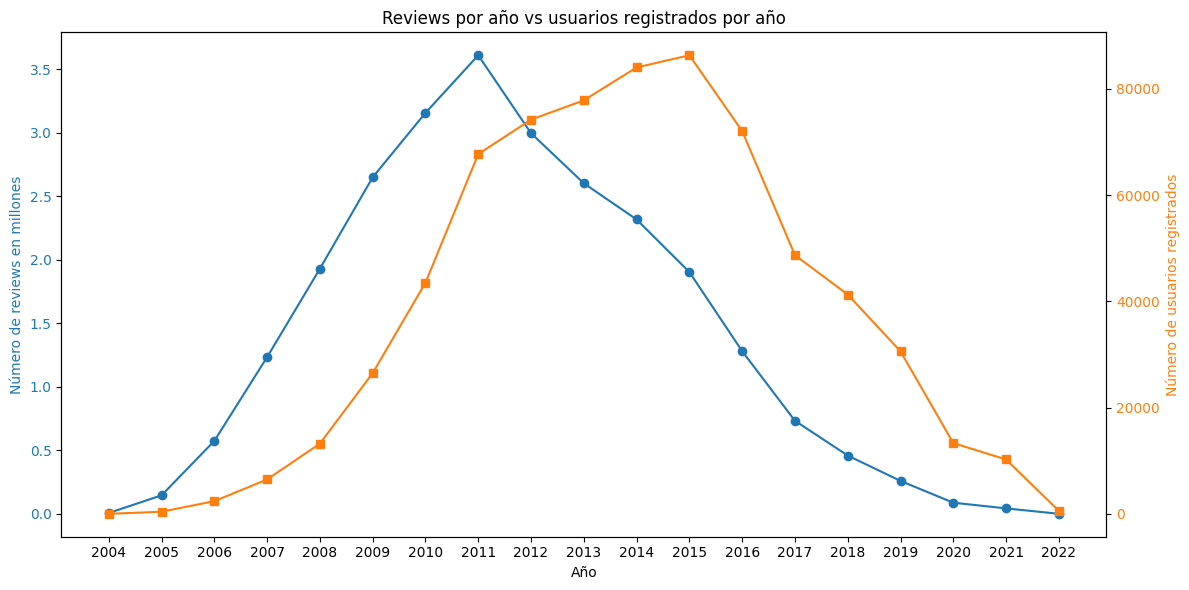

In [48]:
import matplotlib.pyplot as plt

usuarios_anio = usuarios.with_columns(
    pl.col("yelping_since").dt.year().alias("anio")
)

df_plot = (
    duckdb.sql("""
        SELECT
            anio,
            COUNT(*) AS usuarios_registrados,
            SUM(review_count) AS total_reviews
        FROM usuarios_anio
        GROUP BY anio
        ORDER BY anio
    """)
    .pl()
    .with_columns(
        pl.col("anio").cast(pl.Utf8),  # fuerza mostrar años completos en eje X
        (pl.col("total_reviews").cast(pl.Float64) / 1_000_000).alias("total_reviews"),  # eje Y azul en millones
    )
)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    df_plot["anio"].to_numpy(),
    df_plot["total_reviews"].to_numpy(),
    marker="o",
    color="tab:blue",
    label="Reviews"
)
ax1.set_xlabel("Año")
ax1.set_ylabel("Número de reviews en millones", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
    df_plot["anio"].to_numpy(),
    df_plot["usuarios_registrados"].to_numpy(),
    marker="s",
    color="tab:orange",
    label="Usuarios registrados"
)
ax2.set_ylabel("Número de usuarios registrados", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Reviews por año vs usuarios registrados por año")
fig.tight_layout()
plt.show()

### Distribuciuon de calificaicones.

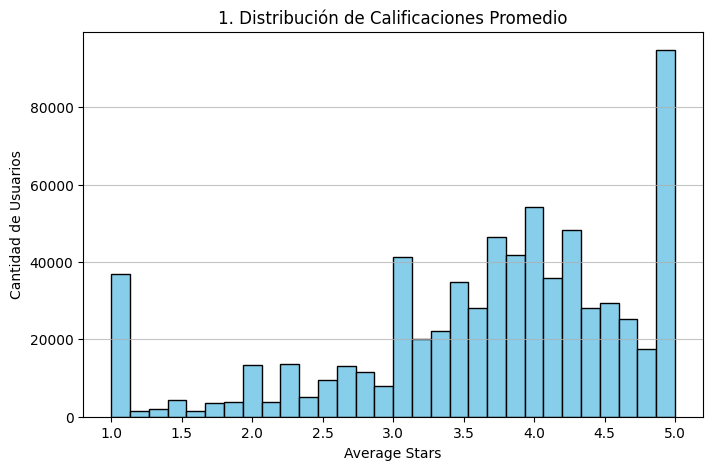

In [13]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT average_stars FROM usuarios WHERE average_stars IS NOT NULL").pl()
plt.hist(data['average_stars'], bins=30, color='skyblue', edgecolor='black')
plt.title('1. Distribución de Calificaciones Promedio')
plt.xlabel('Average Stars')
plt.ylabel('Cantidad de Usuarios')
plt.grid(axis='y', alpha=0.75)
plt.show()

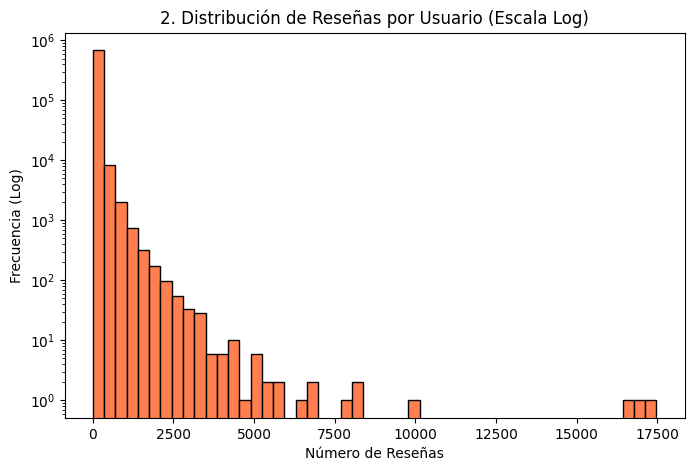

In [14]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT review_count FROM usuarios WHERE review_count > 0").pl()
plt.hist(data['review_count'], bins=50, color='coral', log=True, edgecolor='black')
plt.title('2. Distribución de Reseñas por Usuario (Escala Log)')
plt.xlabel('Número de Reseñas')
plt.ylabel('Frecuencia (Log)')
plt.show()

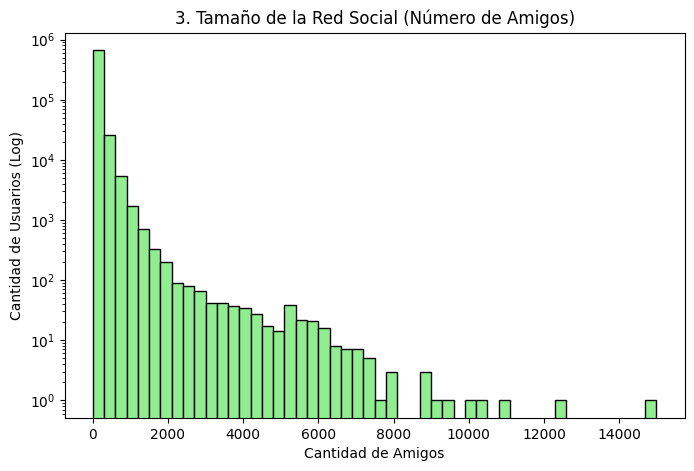

In [20]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT length(friends) as num_friends FROM usuarios").pl()
plt.hist(data['num_friends'], bins=50, color='lightgreen', log=True, edgecolor='black')
plt.title('3. Tamaño de la Red Social (Número de Amigos)')
plt.xlabel('Cantidad de Amigos')
plt.ylabel('Cantidad de Usuarios (Log)')
plt.show()

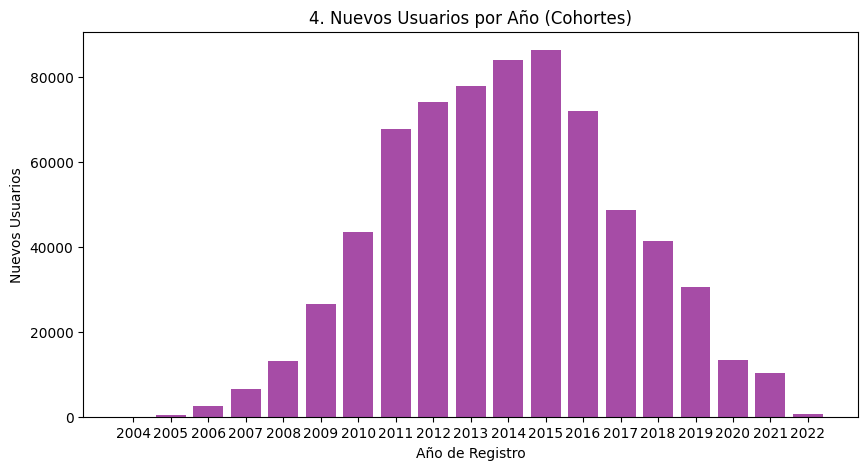

In [24]:
plt.figure(figsize=(10, 5))
data = duckdb.sql("""
    SELECT EXTRACT(year FROM yelping_since) as join_year, COUNT(*) as user_count 
    FROM usuarios 
    GROUP BY join_year 
    ORDER BY join_year
""").pl()

plt.bar(data['join_year'], data['user_count'], color='purple', alpha=0.7)
plt.xticks(data['join_year'].to_list())
plt.title('4. Nuevos Usuarios por Año (Cohortes)')
plt.xlabel('Año de Registro')
plt.ylabel('Nuevos Usuarios')
plt.show()

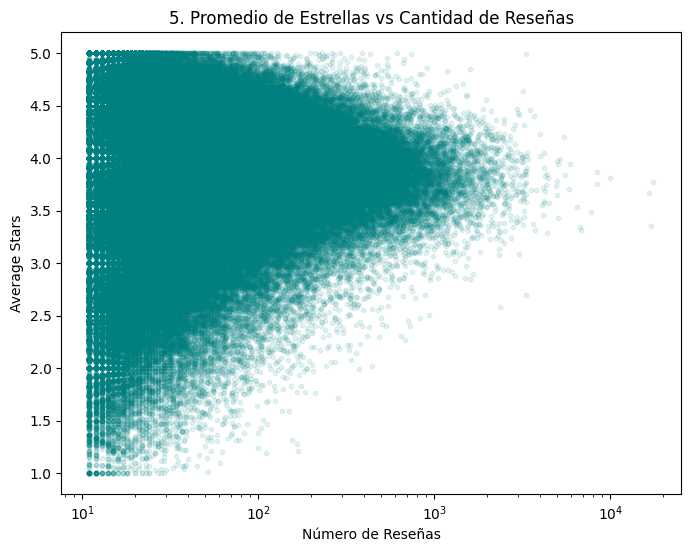

In [25]:
plt.figure(figsize=(8, 6))
data = duckdb.sql("SELECT review_count, average_stars FROM usuarios WHERE review_count > 10").pl()
plt.scatter(data['review_count'], data['average_stars'], alpha=0.1, color='teal', s=10)
plt.title('5. Promedio de Estrellas vs Cantidad de Reseñas')
plt.xlabel('Número de Reseñas')
plt.ylabel('Average Stars')
plt.xscale('log')
plt.show()

/tmp/ipykernel_23701/2740232827.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([np.log1p(data['useful']), np.log1p(data['funny']), np.log1p(data['cool'])],


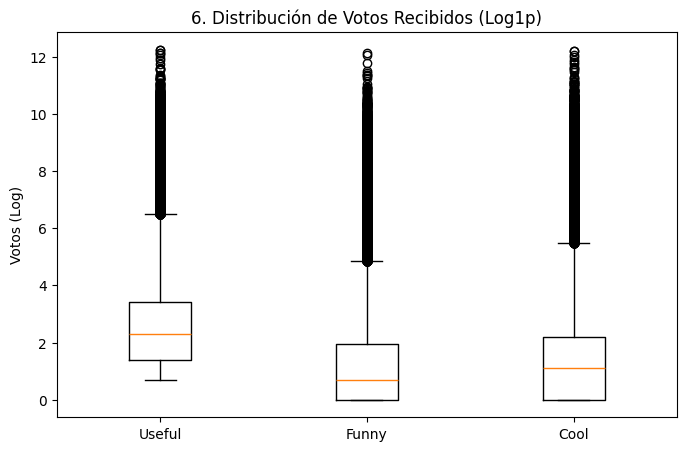

In [26]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT useful, funny, cool FROM usuarios WHERE useful > 0").pl()
plt.boxplot([np.log1p(data['useful']), np.log1p(data['funny']), np.log1p(data['cool'])], 
            labels=['Useful', 'Funny', 'Cool'])
plt.title('6. Distribución de Votos Recibidos (Log1p)')
plt.ylabel('Votos (Log)')
plt.show()

/tmp/ipykernel_23701/3355346442.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([np.log1p(normal_counts), np.log1p(elite_counts)], labels=['Normal', 'Elite'])


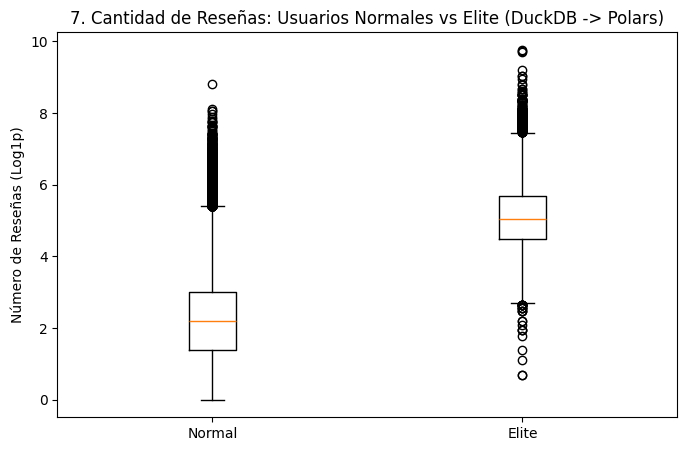

In [45]:
# 1. Consulta SQL con DuckDB y exportación directa a Polars usando .pl()
# Derivemos la columna 'status' directamente dentro de la consulta SQL para optimizar
query_status = """
    SELECT 
        review_count, 
        CASE 
            WHEN len(elite) > 0 THEN 'Elite' 
            ELSE 'Normal' 
        END as status
    FROM usuarios
    WHERE review_count IS NOT NULL -- excluimos nulos para la transformación logarítmica
"""

# df_status_pl es ahora un DataFrame de Polars (Cero copias, integración via Arrow)
df_status_pl = duckdb.sql(query_status).pl()

# 2. Extracción eficiente de los datos para Matplotlib (usando NumPy)
# Filtramos y convertimos a numpy array directamente desde la columna Series de Polars
elite_counts = (
    df_status_pl
    .filter(pl.col("status") == "Elite")
    .get_column("review_count")
    .to_numpy()
)

normal_counts = (
    df_status_pl
    .filter(pl.col("status") == "Normal")
    .get_column("review_count")
    .to_numpy()
)

# 3. Visualización con Matplotlib
plt.figure(figsize=(8, 5))

# Creamos los boxplots usando log1p para manejar ceros y visualizar mejor la distribución sesgada
# Usamos log1p(normal_counts) y log1p(elite_counts) para la transformación logarítmica
plt.boxplot([np.log1p(normal_counts), np.log1p(elite_counts)], labels=['Normal', 'Elite'])

# Configuramos título y etiquetas en español
plt.title('7. Cantidad de Reseñas: Usuarios Normales vs Elite (DuckDB -> Polars)')
plt.ylabel('Número de Reseñas (Log1p)')

# Mostramos el gráfico
plt.show()

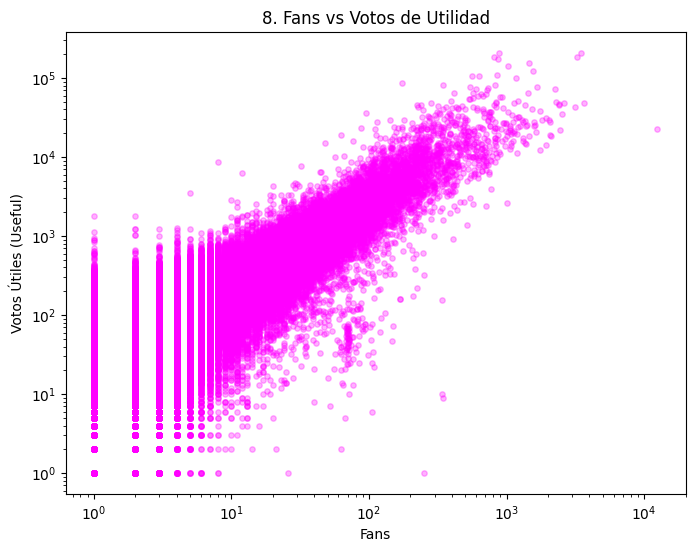

In [35]:
plt.figure(figsize=(8, 6))
data = duckdb.sql("SELECT fans, useful FROM usuarios WHERE fans > 0 AND useful > 0").pl()
plt.scatter(data['fans'], data['useful'], alpha=0.3, color='magenta', s=15)
plt.title('8. Fans vs Votos de Utilidad')
plt.xlabel('Fans')
plt.ylabel('Votos Útiles (Useful)')
plt.xscale('log')
plt.yscale('log')
plt.show()

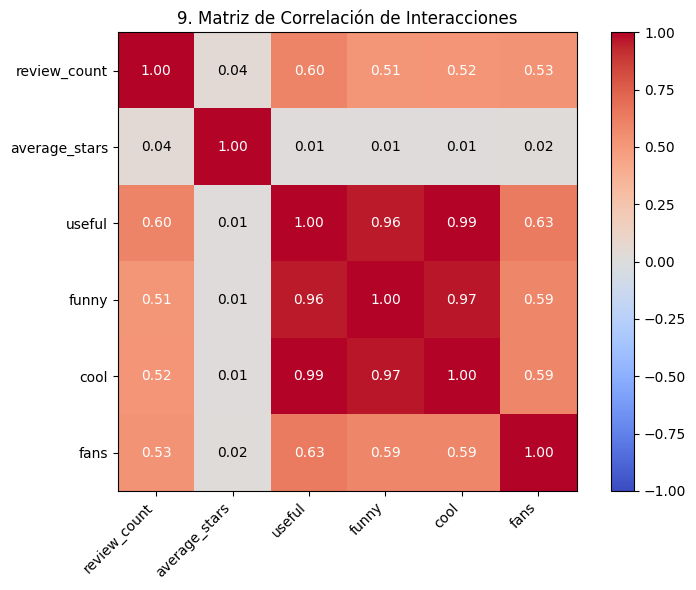

In [43]:
# 1. Consulta SQL con DuckDB y exportación directa a Polars usando .pl()
# Usamos solo las columnas originales de tu dataset
query = """
    SELECT 
        review_count, 
        average_stars, 
        useful, 
        funny, 
        cool, 
        fans 
    FROM usuarios
"""

# df_corr es ahora un DataFrame de Polars (Cero copias, integración via Arrow)
df_corr = duckdb.sql(query).pl()

# 2. Cálculo de la matriz de correlación
# Extraemos los nombres de las columnas para las etiquetas
column_names = df_corr.columns

# Pasamos los datos a NumPy de forma eficiente para calcular la correlación
# rowvar=False indica que las columnas son las variables (features)
corr_matrix = np.corrcoef(df_corr.to_numpy(), rowvar=False)

# 3. Visualización con Matplotlib
plt.figure(figsize=(8, 6))

# Dibujamos el mapa de calor (heatmap)
cax = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

# Configuramos las etiquetas de los ejes X e Y
ticks = np.arange(0, len(column_names), 1)
plt.xticks(ticks, column_names, rotation=45, ha='right')
plt.yticks(ticks, column_names)

plt.title('9. Matriz de Correlación de Interacciones')

# Añadimos los valores numéricos dentro de cada celda para que sea legible
for i in range(len(column_names)):
    for j in range(len(column_names)):
        # Añadimos el valor redondeado a 2 decimales
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}", 
                 ha="center", va="center", color="black" if abs(corr_matrix[i, j]) < 0.5 else "white")

# Ajustamos el layout para que los textos rotados no se corten
plt.tight_layout()
plt.show()

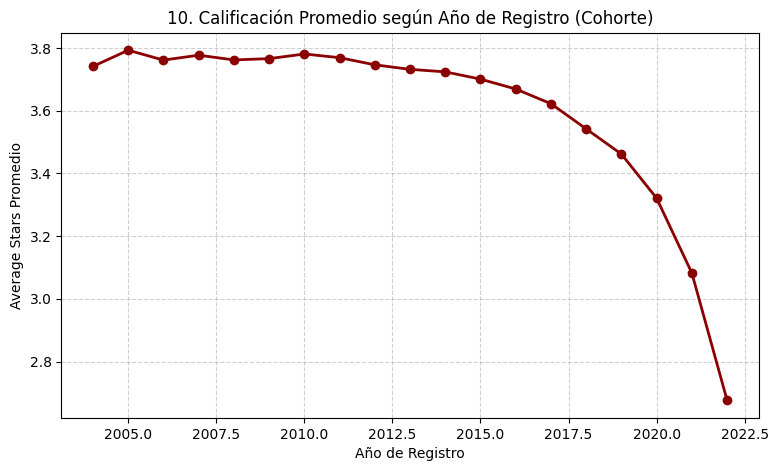

In [40]:
plt.figure(figsize=(9, 5))
data = duckdb.sql("""
    SELECT EXTRACT(year FROM yelping_since) as join_year, AVG(average_stars) as mean_stars 
    FROM usuarios
    GROUP BY join_year 
    ORDER BY join_year
""").pl()

plt.plot(data['join_year'], data['mean_stars'], marker='o', linestyle='-', color='darkred', linewidth=2)
plt.title('10. Calificación Promedio según Año de Registro (Cohorte)')
plt.xlabel('Año de Registro')
plt.ylabel('Average Stars Promedio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Negocios

In [10]:
negocios = pl.read_csv(
    "../data/negocios.csv",
    separator=",",
    schema_overrides={
        "business_id": pl.Utf8,
        "name": pl.Utf8,
        "address": pl.Utf8,
        "city": pl.Utf8,
        "state": pl.Utf8,
        "postal_code": pl.Utf8,   # en algunos archivos puede venir como "postal code"
        "postal code": pl.Utf8,
        "latitude": pl.Float64,
        "longitude": pl.Float64,
        "stars": pl.Float64,
        "review_count": pl.Int64,
        "is_open": pl.Int8,
        "attributes": pl.Utf8,    # objeto (normalmente llega como texto/JSON en CSV)
        "categories": pl.Utf8,    # array/lista (normalmente llega como texto en CSV)
        "hours": pl.Utf8,         # objeto (normalmente llega como texto/JSON en CSV)
    },
    ignore_errors=True,
)

if "postal code" in negocios.columns and "postal_code" not in negocios.columns:
    negocios = negocios.rename({"postal code": "postal_code"})

# 1) categories -> List[str]
negocios = negocios.with_columns(
    pl.when(
        pl.col("categories").is_null() | pl.col("categories").str.strip_chars().is_in(["", "None"])
    )
    .then(pl.lit([]).cast(pl.List(pl.Utf8)))
    .otherwise(
        pl.col("categories")
        .str.split(",")
        .list.eval(pl.element().str.strip_chars())
    )
    .alias("categories")
)


negocios.head(5)

business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
str,str,str,str,str,str,f64,f64,f64,i64,i8,str,list[str],str
"""GDEEPQdYs2utMN-R4znZSA""","""Metro Self Storage - Largo""","""10501 S Belcher Rd""","""Largo""","""FL""","""33777""",27.868519,-82.743849,4.5,7,0,"""{'BusinessAcceptsCreditCards':…","[""Packing Supplies"", ""Shopping"", … ""Self Storage""]","""{'Monday': '0:0-0:0', 'Tuesday…"
"""pbAq2NRG_2jCBI6fgRalvQ""","""Madewell""","""3301 Veterans Blvd, Ste 84""","""Metairie""","""LA""","""70002""",30.005894,-90.15745,2.0,6,1,"""{'BusinessAcceptsCreditCards':…","[""Shopping"", ""Women's Clothing"", … ""Accessories""]","""{'Monday': '10:0-21:0', 'Tuesd…"
"""h4HP3Vc0dQq7SfSLal9qQw""","""Dollylocks""","""511 9th St N""","""Saint Petersburg""","""FL""","""33701""",27.777785,-82.646673,4.5,7,0,"""{'RestaurantsPriceRange2': '4'…","[""Hair Stylists"", ""Beauty & Spas"", … ""Hair Extensions""]",null
"""PndbFVbHE4730HDlghxv6g""","""Jim Browne Chrysler Jeep Dodge…","""10909 N Florida Ave""","""Tampa""","""FL""","""33612""",28.048093,-82.458757,2.5,76,1,"""{'BusinessAcceptsCreditCards':…","[""Automotive"", ""Auto Parts & Supplies"", … ""Auto Repair""]","""{'Monday': '7:30-20:0', 'Tuesd…"
"""IayDnngl0NooAbcoo62j-w""","""Emg Salons""","""324 S Falkenburg Rd""","""Tampa""","""FL""","""33619""",27.948815,-82.334619,4.5,7,1,"""{'WiFi': ""u'free'"", 'BikeParki…","[""Hair Stylists"", ""Hair Salons"", … ""Cosmetics & Beauty Supply""]","""{'Tuesday': '9:0-20:0', 'Wedne…"


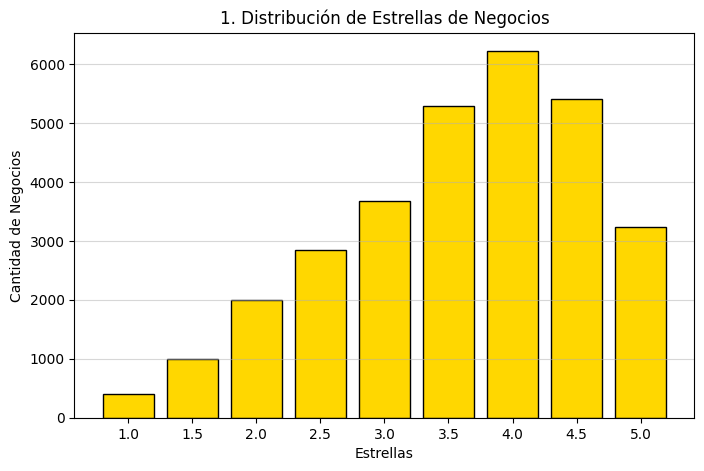

In [14]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT stars FROM negocios WHERE stars IS NOT NULL").pl()
# Usamos np.unique para contar las frecuencias de cada estrella (2.0, 2.5, 3.0...)
stars, counts = np.unique(data['stars'].to_numpy(), return_counts=True)
plt.bar(stars, counts, width=0.4, color='gold', edgecolor='black')
plt.title('1. Distribución de Estrellas de Negocios')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de Negocios')
plt.xticks(stars)
plt.grid(axis='y', alpha=0.5)
plt.show()

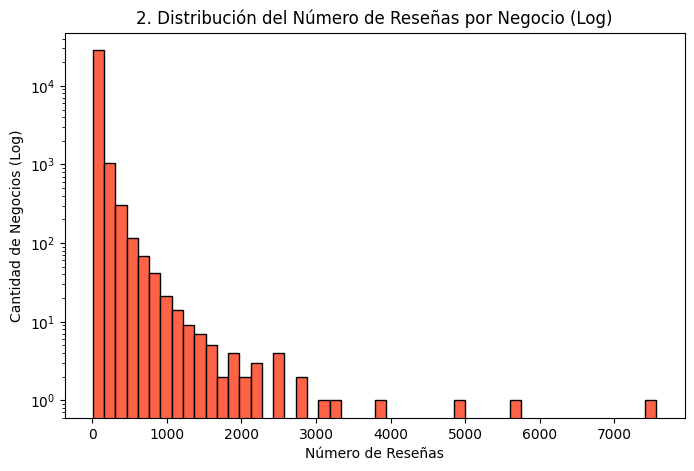

In [15]:
plt.figure(figsize=(8, 5))
data = duckdb.sql("SELECT review_count FROM negocios WHERE review_count > 0").pl()
plt.hist(data['review_count'], bins=50, color='tomato', log=True, edgecolor='black')
plt.title('2. Distribución del Número de Reseñas por Negocio (Log)')
plt.xlabel('Número de Reseñas')
plt.ylabel('Cantidad de Negocios (Log)')
plt.show()

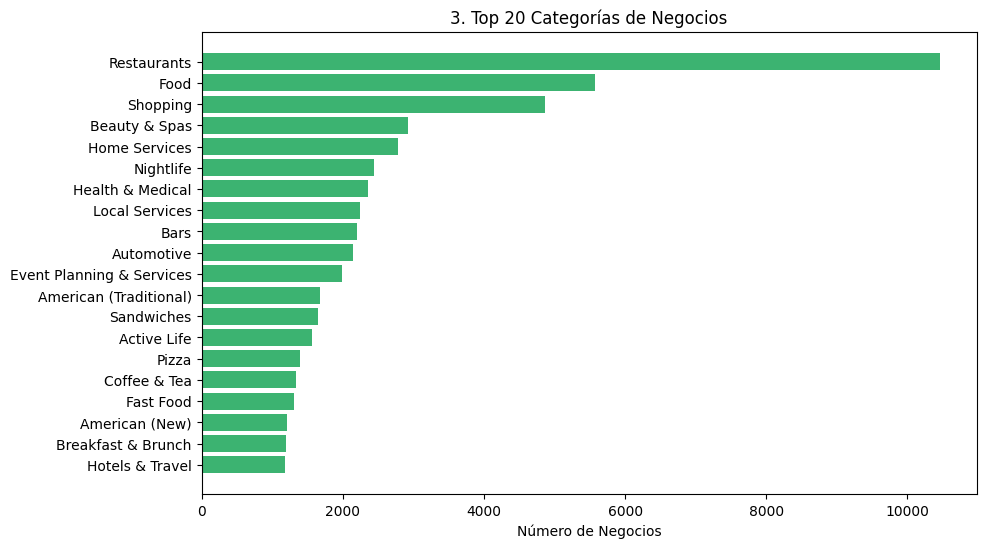

In [16]:
plt.figure(figsize=(10, 6))
query = """
    SELECT category, COUNT(*) as count
    FROM (
        SELECT UNNEST(categories) as category FROM negocios
    )
    GROUP BY category
    ORDER BY count DESC
    LIMIT 20
"""
data = duckdb.sql(query).pl()

# Gráfico de barras horizontal para que se lean bien los textos
plt.barh(data['category'], data['count'], color='mediumseagreen')
plt.gca().invert_yaxis() # La categoría más grande arriba
plt.title('3. Top 20 Categorías de Negocios')
plt.xlabel('Número de Negocios')
plt.show()

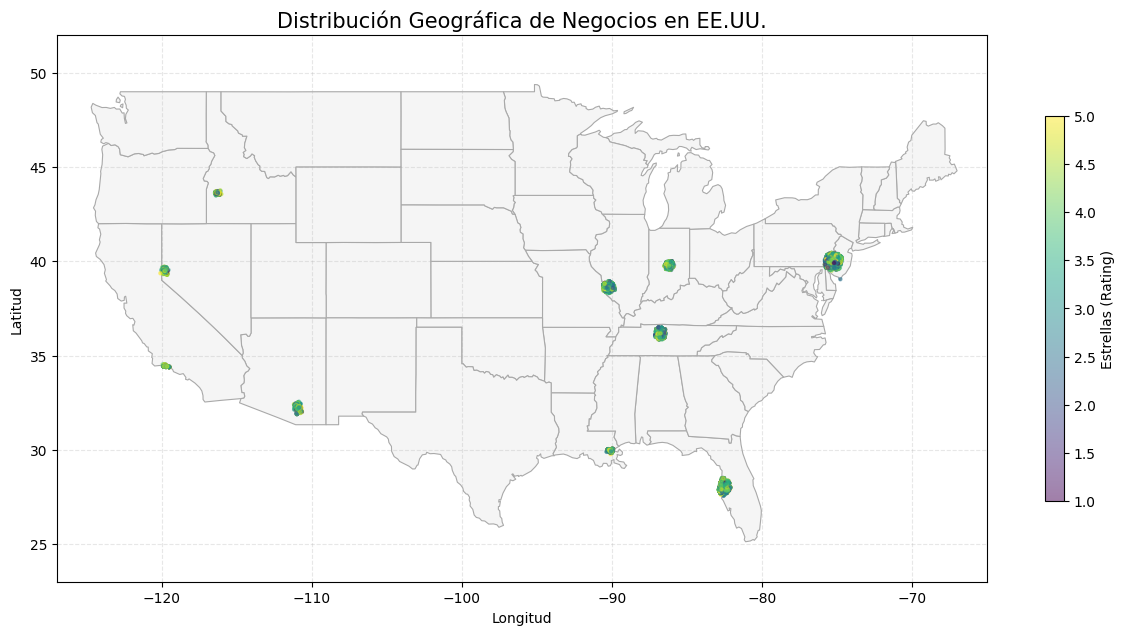

In [29]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. Obtener los datos con DuckDB -> Polars
query = """
    SELECT longitude, latitude, stars 
    FROM negocios 
    WHERE longitude IS NOT NULL AND latitude IS NOT NULL
      AND longitude BETWEEN -125 AND -66 -- Límites de EE.UU. contiguo
      AND latitude BETWEEN 24 AND 50
"""
data = duckdb.sql(query).pl()

# 2. Cargar el mapa base (Solución actualizada sin error de versión)
# Usamos un GeoJSON público de alta calidad con las fronteras de los estados
url_usa_states = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
usa = gpd.read_file(url_usa_states)

# Excluimos Alaska y Hawaii para mantener el foco en la península y evitar que el mapa se "aleje" mucho
usa = usa[~usa['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])]

# 3. Crear la visualización
fig, ax = plt.subplots(figsize=(15, 10))

# Dibujar el fondo del mapa (ahora con bordes estatales en gris oscuro)
usa.plot(ax=ax, color='whitesmoke', edgecolor='darkgrey', linewidth=0.8)

# Superponer los puntos de los negocios
scatter = ax.scatter(
    data['longitude'], 
    data['latitude'], 
    c=data['stars'], 
    cmap='viridis', 
    alpha=0.5, 
    s=5, # Puntos pequeños
    zorder=2 # Asegura que los puntos se dibujen por encima del mapa
)

# Estética y etiquetas
plt.colorbar(scatter, label='Estrellas (Rating)', shrink=0.5)
plt.title('Distribución Geográfica de Negocios en EE.UU.', fontsize=15)
plt.xlabel('Longitud')
plt.ylabel('Latitud')

# Forzar los límites para centrar bien la vista
ax.set_xlim([-127, -65])
ax.set_ylim([23, 52])

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

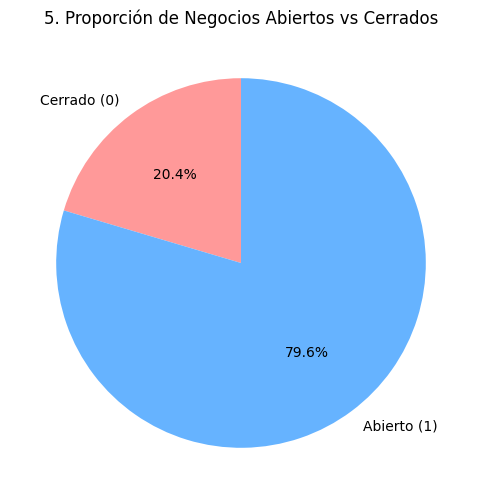

In [19]:
plt.figure(figsize=(6, 6))
data = duckdb.sql("SELECT is_open, COUNT(*) as count FROM negocios GROUP BY is_open").pl()

labels = ['Cerrado (0)', 'Abierto (1)']
# Ajustamos los labels dependiendo de cómo los devuelva la query
counts = [
    data.filter(pl.col("is_open") == 0)['count'][0],
    data.filter(pl.col("is_open") == 1)['count'][0]
]

plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('5. Proporción de Negocios Abiertos vs Cerrados')
plt.show()

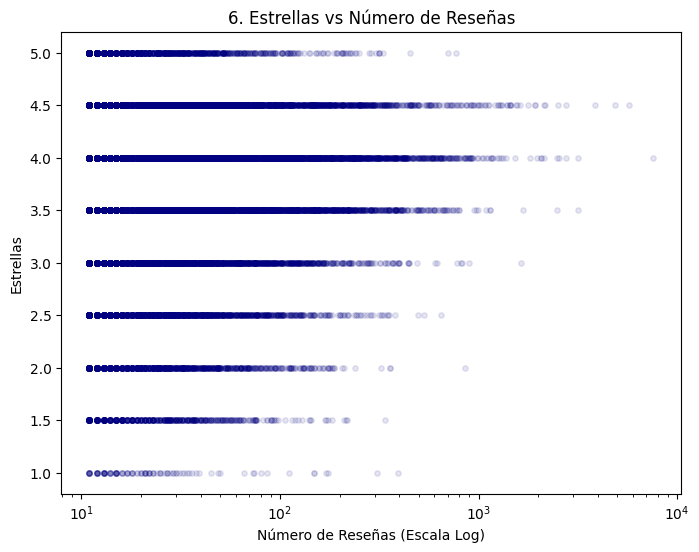

In [20]:
plt.figure(figsize=(8, 6))
data = duckdb.sql("SELECT review_count, stars FROM negocios WHERE review_count > 10").pl()

plt.scatter(data['review_count'], data['stars'], alpha=0.1, color='navy', s=15)
plt.title('6. Estrellas vs Número de Reseñas')
plt.xlabel('Número de Reseñas (Escala Log)')
plt.ylabel('Estrellas')
plt.xscale('log')
plt.show()

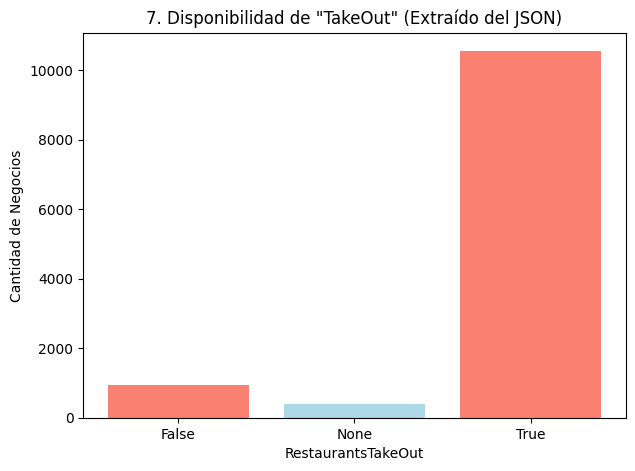

In [23]:
plt.figure(figsize=(7, 5))
# Extraemos el valor de RestaurantsTakeOut directamente del string JSON
query = """
    SELECT 
        json_extract_string(attributes, '$.RestaurantsTakeOut') as take_out,
        COUNT(*) as count
    FROM negocios
    WHERE attributes IS NOT NULL AND json_extract_string(attributes, '$.RestaurantsTakeOut') IS NOT NULL
    GROUP BY take_out
"""
data = (
    negocios
    .select(
        pl.col("attributes")
        .str.extract(r"'RestaurantsTakeOut':\s*'([^']*)'", 1)
        .alias("take_out")
    )
    .drop_nulls()
    .group_by("take_out")
    .agg(pl.len().alias("count"))
    .sort("take_out")
)

plt.bar(data['take_out'], data['count'], color=['salmon', 'lightblue'])
plt.title('7. Disponibilidad de "TakeOut" (Extraído del JSON)')
plt.xlabel('RestaurantsTakeOut')
plt.ylabel('Cantidad de Negocios')
plt.show()

/tmp/ipykernel_49841/501558755.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=categories)


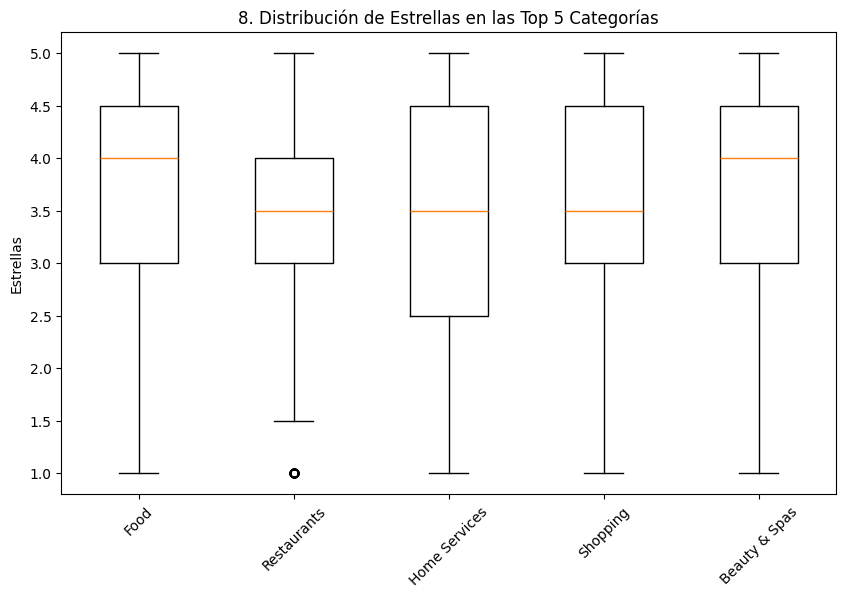

In [22]:
plt.figure(figsize=(10, 6))
# Subquery 1: Saca las 5 top. Subquery 2: Hace join con las estrellas usando UNNEST
query = """
    WITH top_cats AS (
        SELECT category FROM (SELECT UNNEST(categories) as category FROM negocios)
        GROUP BY category ORDER BY COUNT(*) DESC LIMIT 5
    )
    SELECT t.category, d.stars
    FROM negocios d, UNNEST(d.categories) AS t(category)
    WHERE t.category IN (SELECT category FROM top_cats)
"""
data = duckdb.sql(query).pl()

# Preparamos los datos para un boxplot agrupado
categories = data['category'].unique().to_list()
plot_data = [data.filter(pl.col("category") == c)['stars'].to_numpy() for c in categories]

plt.boxplot(plot_data, labels=categories)
plt.title('8. Distribución de Estrellas en las Top 5 Categorías')
plt.ylabel('Estrellas')
plt.xticks(rotation=45)
plt.show()

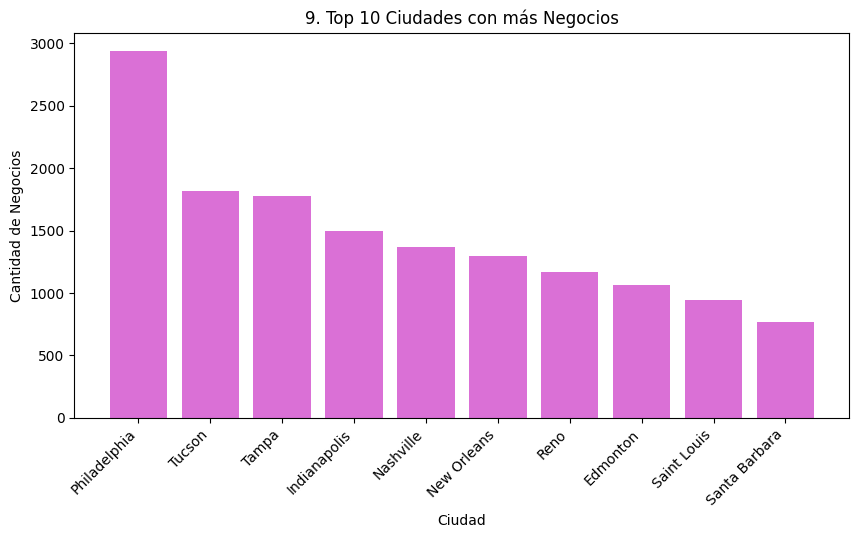

In [24]:
plt.figure(figsize=(10, 5))
query = "SELECT city, COUNT(*) as count FROM negocios GROUP BY city ORDER BY count DESC LIMIT 10"
data = duckdb.sql(query).pl()

plt.bar(data['city'], data['count'], color='orchid')
plt.title('9. Top 10 Ciudades con más Negocios')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de Negocios')
plt.xticks(rotation=45, ha='right')
plt.show()

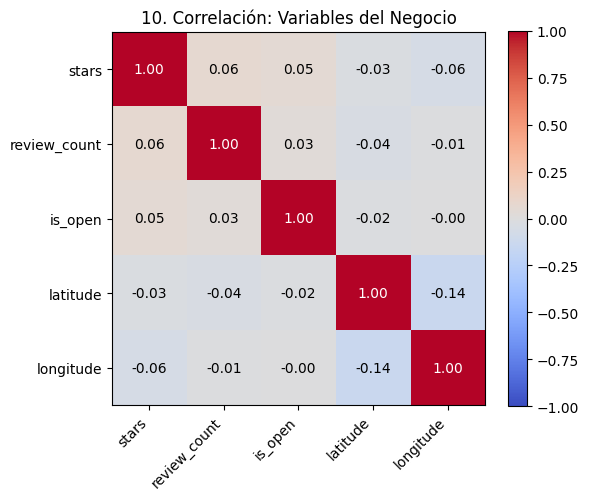

In [26]:
# La verdad es que este no tenia ningun sentido
plt.figure(figsize=(6, 5))
query = "SELECT stars, review_count, is_open, latitude, longitude FROM negocios"
df_corr = duckdb.sql(query).pl()

corr_matrix = np.corrcoef(df_corr.to_numpy(), rowvar=False)
column_names = df_corr.columns

cax = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax)

ticks = np.arange(0, len(column_names), 1)
plt.xticks(ticks, column_names, rotation=45, ha='right')
plt.yticks(ticks, column_names)
plt.title('10. Correlación: Variables del Negocio')

for i in range(len(column_names)):
    for j in range(len(column_names)):
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}", 
                 ha="center", va="center", color="black" if abs(corr_matrix[i, j]) < 0.5 else "white")

plt.tight_layout()
plt.show()

# Train & Test

In [33]:
df_train = pl.read_csv("../data/train_reviews.csv", try_parse_dates=True)
df_test = pl.read_csv("../data/test_reviews.csv", try_parse_dates=True)

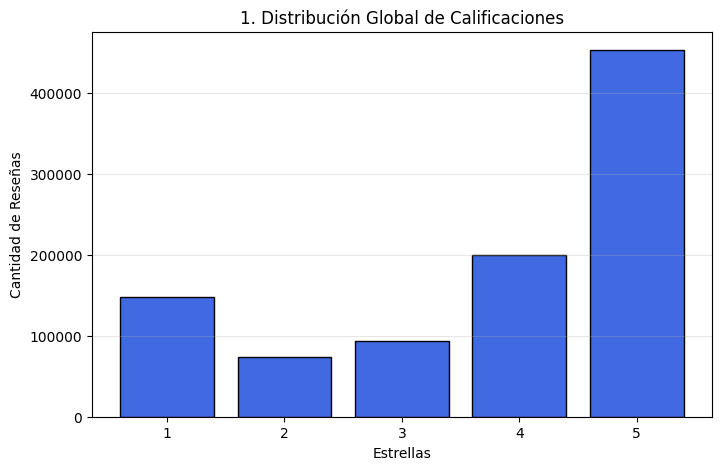

In [35]:
# Asumimos que el dataframe se llama df_train
# 1. Extraemos conteo de estrellas
query = """
    SELECT stars, COUNT(*) as count 
    FROM df_train 
    WHERE stars IS NOT NULL 
    GROUP BY stars 
    ORDER BY stars
"""
data = duckdb.sql(query).pl()

plt.figure(figsize=(8, 5))
plt.bar(data['stars'], data['count'], color='royalblue', edgecolor='black')
plt.title('1. Distribución Global de Calificaciones')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de Reseñas')
plt.grid(axis='y', alpha=0.3)
plt.show()

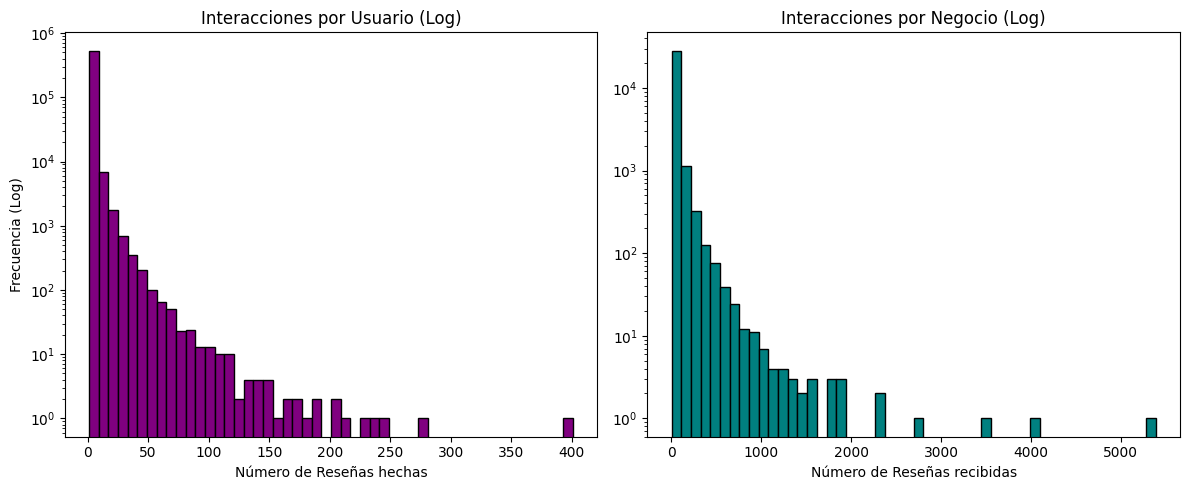

In [36]:
plt.figure(figsize=(12, 5))

# Subplot 1: Sparsity de Usuarios
plt.subplot(1, 2, 1)
query_users = "SELECT COUNT(*) as count FROM df_train GROUP BY user_id"
data_u = duckdb.sql(query_users).pl()
plt.hist(data_u['count'], bins=50, log=True, color='purple', edgecolor='black')
plt.title('Interacciones por Usuario (Log)')
plt.xlabel('Número de Reseñas hechas')
plt.ylabel('Frecuencia (Log)')

# Subplot 2: Sparsity de Negocios
plt.subplot(1, 2, 2)
query_items = "SELECT COUNT(*) as count FROM df_train GROUP BY business_id"
data_i = duckdb.sql(query_items).pl()
plt.hist(data_i['count'], bins=50, log=True, color='teal', edgecolor='black')
plt.title('Interacciones por Negocio (Log)')
plt.xlabel('Número de Reseñas recibidas')

plt.tight_layout()
plt.show()

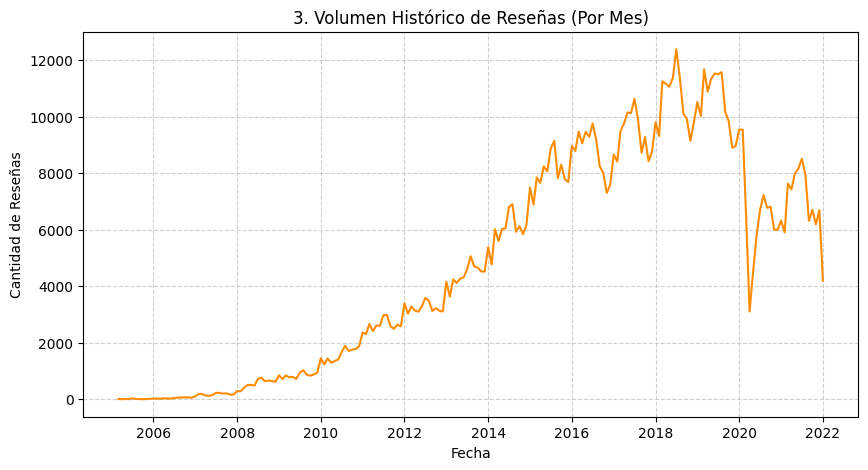

In [37]:
plt.figure(figsize=(10, 5))
# Agrupamos por mes truncando la fecha
query = """
    SELECT date_trunc('month', date) as month, COUNT(*) as count 
    FROM df_train 
    GROUP BY month 
    ORDER BY month
"""
data = duckdb.sql(query).pl()

plt.plot(data['month'].to_numpy(), data['count'].to_numpy(), color='darkorange')
plt.title('3. Volumen Histórico de Reseñas (Por Mes)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Reseñas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

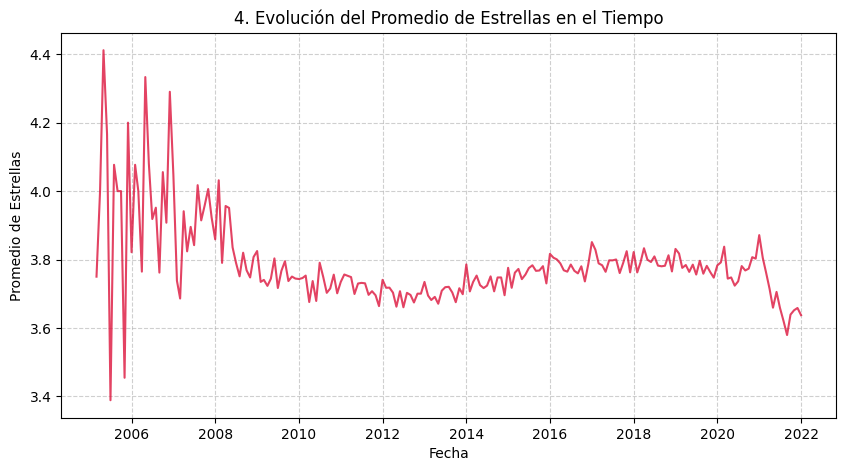

In [38]:
plt.figure(figsize=(10, 5))
query = """
    SELECT date_trunc('month', date) as month, AVG(stars) as avg_stars 
    FROM df_train 
    GROUP BY month 
    ORDER BY month
"""
data = duckdb.sql(query).pl()

# Suavizamos un poco el gráfico (media móvil básica visual con matplotlib)
plt.plot(data['month'].to_numpy(), data['avg_stars'].to_numpy(), color='crimson', alpha=0.8)
plt.title('4. Evolución del Promedio de Estrellas en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Promedio de Estrellas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

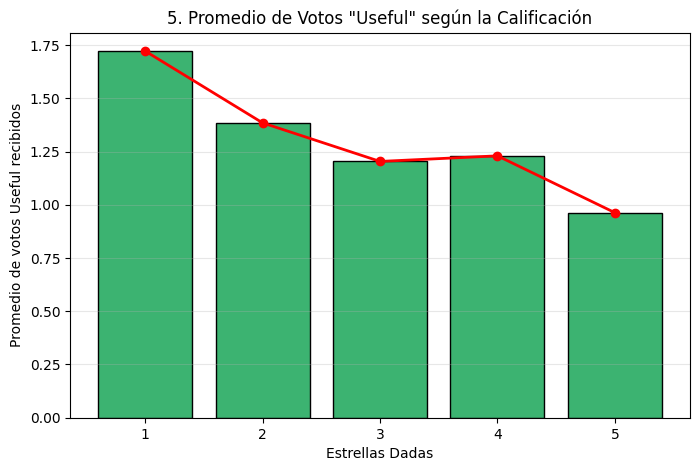

In [39]:
plt.figure(figsize=(8, 5))
query = """
    SELECT stars, AVG(useful) as avg_useful 
    FROM df_train 
    GROUP BY stars 
    ORDER BY stars
"""
data = duckdb.sql(query).pl()

plt.bar(data['stars'], data['avg_useful'], color='mediumseagreen', edgecolor='black')
plt.plot(data['stars'], data['avg_useful'], color='red', marker='o', linewidth=2)
plt.title('5. Promedio de Votos "Useful" según la Calificación')
plt.xlabel('Estrellas Dadas')
plt.ylabel('Promedio de votos Useful recibidos')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Figure size 800x500 with 0 Axes>

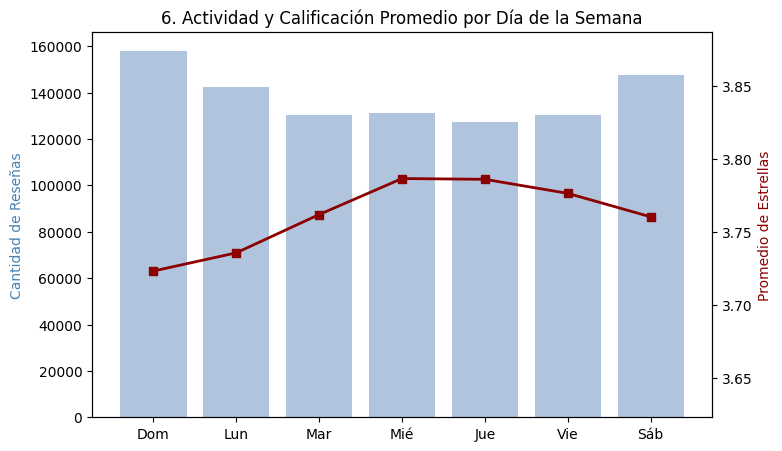

In [40]:
plt.figure(figsize=(8, 5))
# En DuckDB, dayofweek() devuelve 0 (Domingo) a 6 (Sábado)
query = """
    SELECT dayofweek(date) as dow, COUNT(*) as count, AVG(stars) as avg_stars
    FROM df_train 
    GROUP BY dow 
    ORDER BY dow
"""
data = duckdb.sql(query).pl()

dias = ['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb']

fig, ax1 = plt.subplots(figsize=(8, 5))

# Eje principal: Cantidad de reseñas
ax1.bar(dias, data['count'], color='lightsteelblue')
ax1.set_ylabel('Cantidad de Reseñas', color='steelblue')

# Eje secundario: Promedio de estrellas
ax2 = ax1.twinx()
ax2.plot(dias, data['avg_stars'], color='darkred', marker='s', linewidth=2)
ax2.set_ylabel('Promedio de Estrellas', color='darkred')
# Ajustamos los límites de las estrellas para exagerar la diferencia visual si existe
ax2.set_ylim(data['avg_stars'].min() - 0.1, data['avg_stars'].max() + 0.1) 

plt.title('6. Actividad y Calificación Promedio por Día de la Semana')
plt.show()

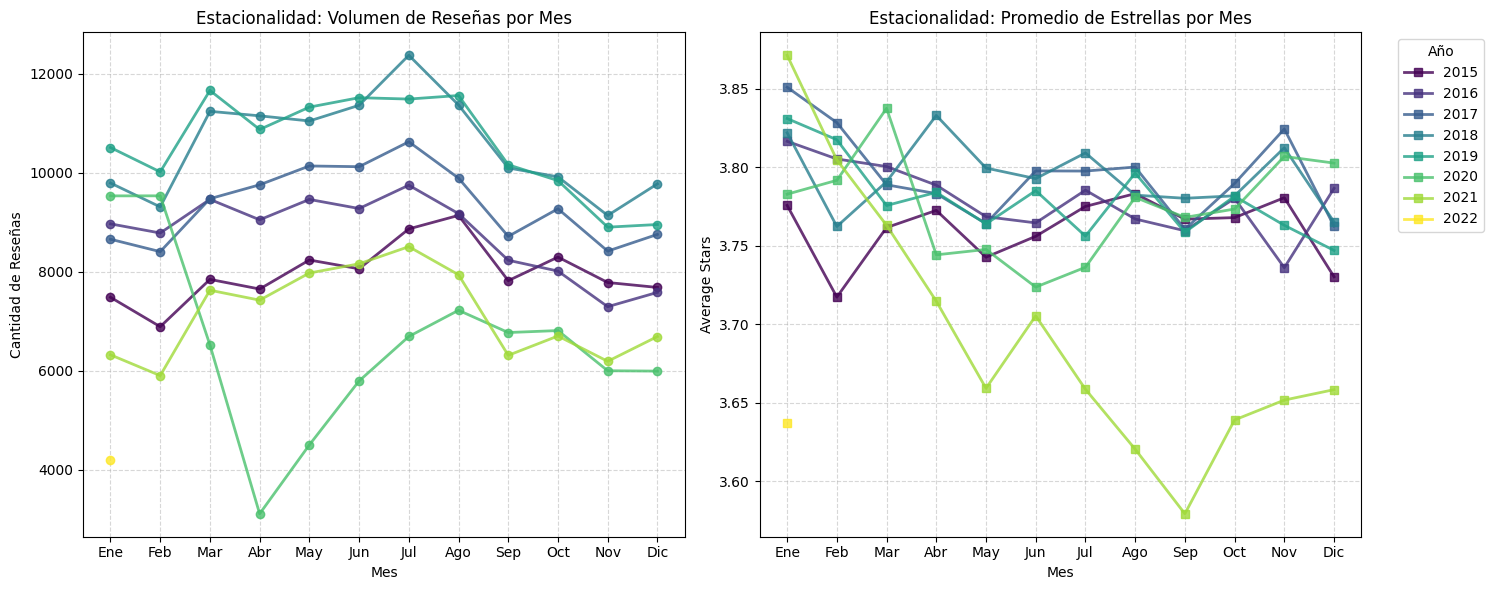

In [41]:
# 1. Extracción de Año y Mes con DuckDB
# Filtramos años muy antiguos o nulos para que el gráfico sea legible
query = """
    SELECT 
        CAST(EXTRACT(year FROM date) AS INT) as year,
        CAST(EXTRACT(month FROM date) AS INT) as month,
        COUNT(*) as count,
        AVG(stars) as avg_stars
    FROM df_train 
    WHERE date IS NOT NULL 
      AND EXTRACT(year FROM date) >= 2015 -- Ajusta este año según tu dataset
    GROUP BY year, month 
    ORDER BY year, month
"""
data = duckdb.sql(query).pl()

# Extraemos la lista de años únicos para iterar
years = data['year'].unique().sort().to_list()

# Configuración de colores (un mapa de colores para distinguir los años)
colores = plt.cm.viridis(np.linspace(0, 1, len(years)))

# 2. Creación del panel doble (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Nombres de los meses para el Eje X
meses_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
meses_x = np.arange(1, 13)

# 3. Dibujar las líneas año por año
for i, year in enumerate(years):
    # Filtramos los datos de ese año específico usando Polars
    df_year = data.filter(pl.col("year") == year)
    
    # Aseguramos que tenemos datos para graficar
    if len(df_year) > 0:
        # Gráfico 1: Volumen de Reseñas
        ax1.plot(df_year['month'], df_year['count'], marker='o', 
                 color=colores[i], label=str(year), alpha=0.8, linewidth=2)
        
        # Gráfico 2: Calidad (Promedio de Estrellas)
        ax2.plot(df_year['month'], df_year['avg_stars'], marker='s', 
                 color=colores[i], label=str(year), alpha=0.8, linewidth=2)

# 4. Estética del Gráfico 1 (Volumen)
ax1.set_title('Estacionalidad: Volumen de Reseñas por Mes')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Cantidad de Reseñas')
ax1.set_xticks(meses_x)
ax1.set_xticklabels(meses_labels)
ax1.grid(True, linestyle='--', alpha=0.5)

# 5. Estética del Gráfico 2 (Promedio de Estrellas)
ax2.set_title('Estacionalidad: Promedio de Estrellas por Mes')
ax2.set_xlabel('Mes')
ax2.set_ylabel('Average Stars')
ax2.set_xticks(meses_x)
ax2.set_xticklabels(meses_labels)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(title='Año', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

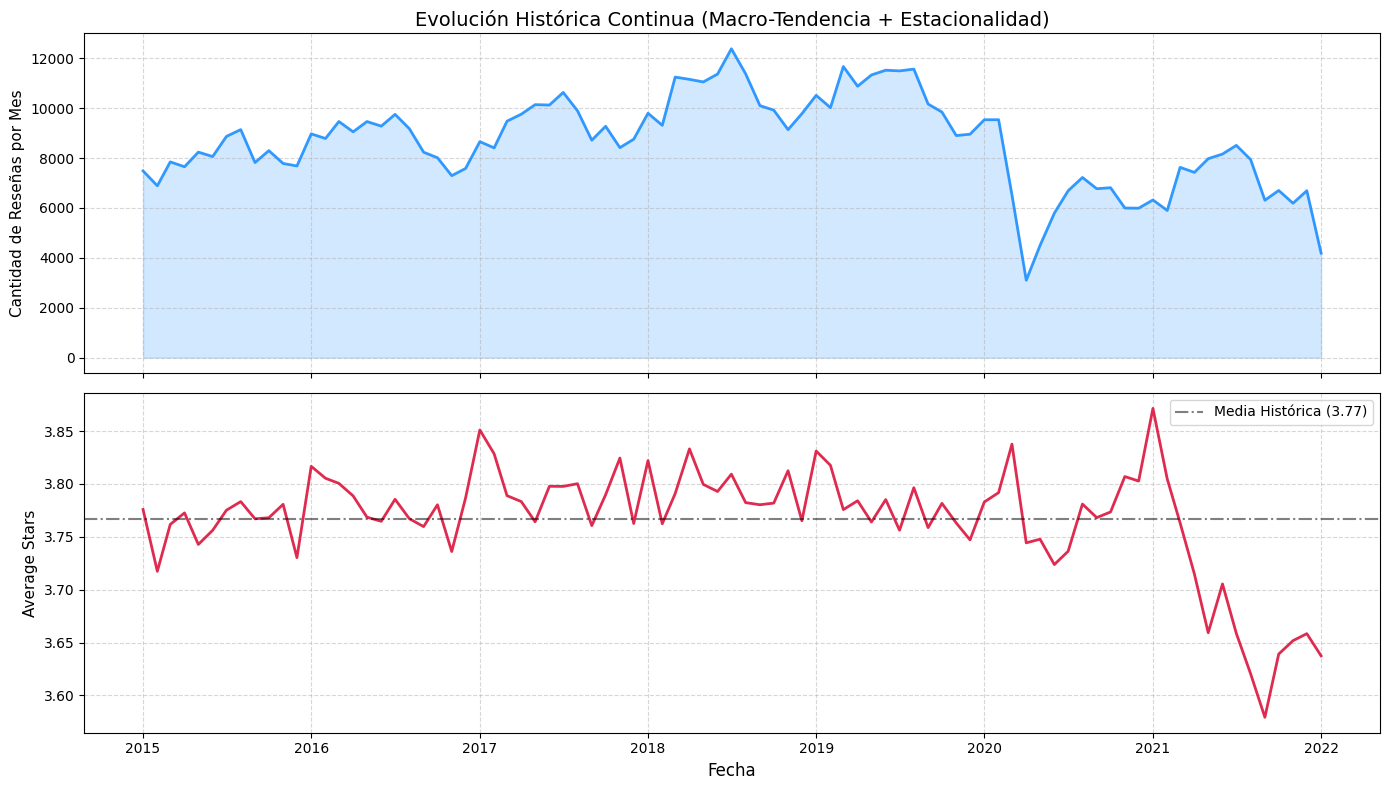

In [42]:
# 1. Agrupación continua por mes con DuckDB
query = """
    SELECT 
        CAST(date_trunc('month', date) AS DATE) as month_start,
        COUNT(*) as count,
        AVG(stars) as avg_stars
    FROM df_train 
    WHERE date IS NOT NULL 
      AND EXTRACT(year FROM date) >= 2015 -- Ajusta según tu dataset
    GROUP BY month_start 
    ORDER BY month_start
"""
# Extraemos a Polars
data = duckdb.sql(query).pl()

# 2. Creación de la figura con dos subgráficos que comparten el Eje X
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Eje temporal
x_fechas = data['month_start'].to_list()

# --- Subgráfico 1: Volumen Histórico ---
ax1.plot(x_fechas, data['count'].to_list(), color='dodgerblue', linewidth=2, alpha=0.9)
# Rellenamos el área bajo la curva para darle más peso visual al volumen
ax1.fill_between(x_fechas, data['count'].to_list(), color='dodgerblue', alpha=0.2)
ax1.set_title('Evolución Histórica Continua (Macro-Tendencia + Estacionalidad)', fontsize=14)
ax1.set_ylabel('Cantidad de Reseñas por Mes', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Subgráfico 2: Promedio de Estrellas ---
ax2.plot(x_fechas, data['avg_stars'].to_list(), color='crimson', linewidth=2, alpha=0.9)
# Añadimos una línea de tendencia general (promedio global de este periodo)
promedio_global = data['avg_stars'].mean()
ax2.axhline(promedio_global, color='black', linestyle='-.', alpha=0.5, label=f'Media Histórica ({promedio_global:.2f})')

ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Average Stars', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

# Ajustar el layout para que no se pisen los textos
plt.tight_layout()
plt.show()